# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

Check for 2D magnetic field of a magnetized prism.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings
import equinox as eqx
import jax

from pathlib import Path
import matplotlib.colors as mcolors

from hypermagnetics import plots
from hypermagnetics.sources import read_db, configure
from hypermagnetics.fmm_sources import potential2D, field2d_grid
from hypermagnetics.mt_eval import field_mt
from hypermagnetics.models.hyper_mlp import HyperLayer

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

Res: 512 Max size: 0.46842003 Min size: 0.12098971


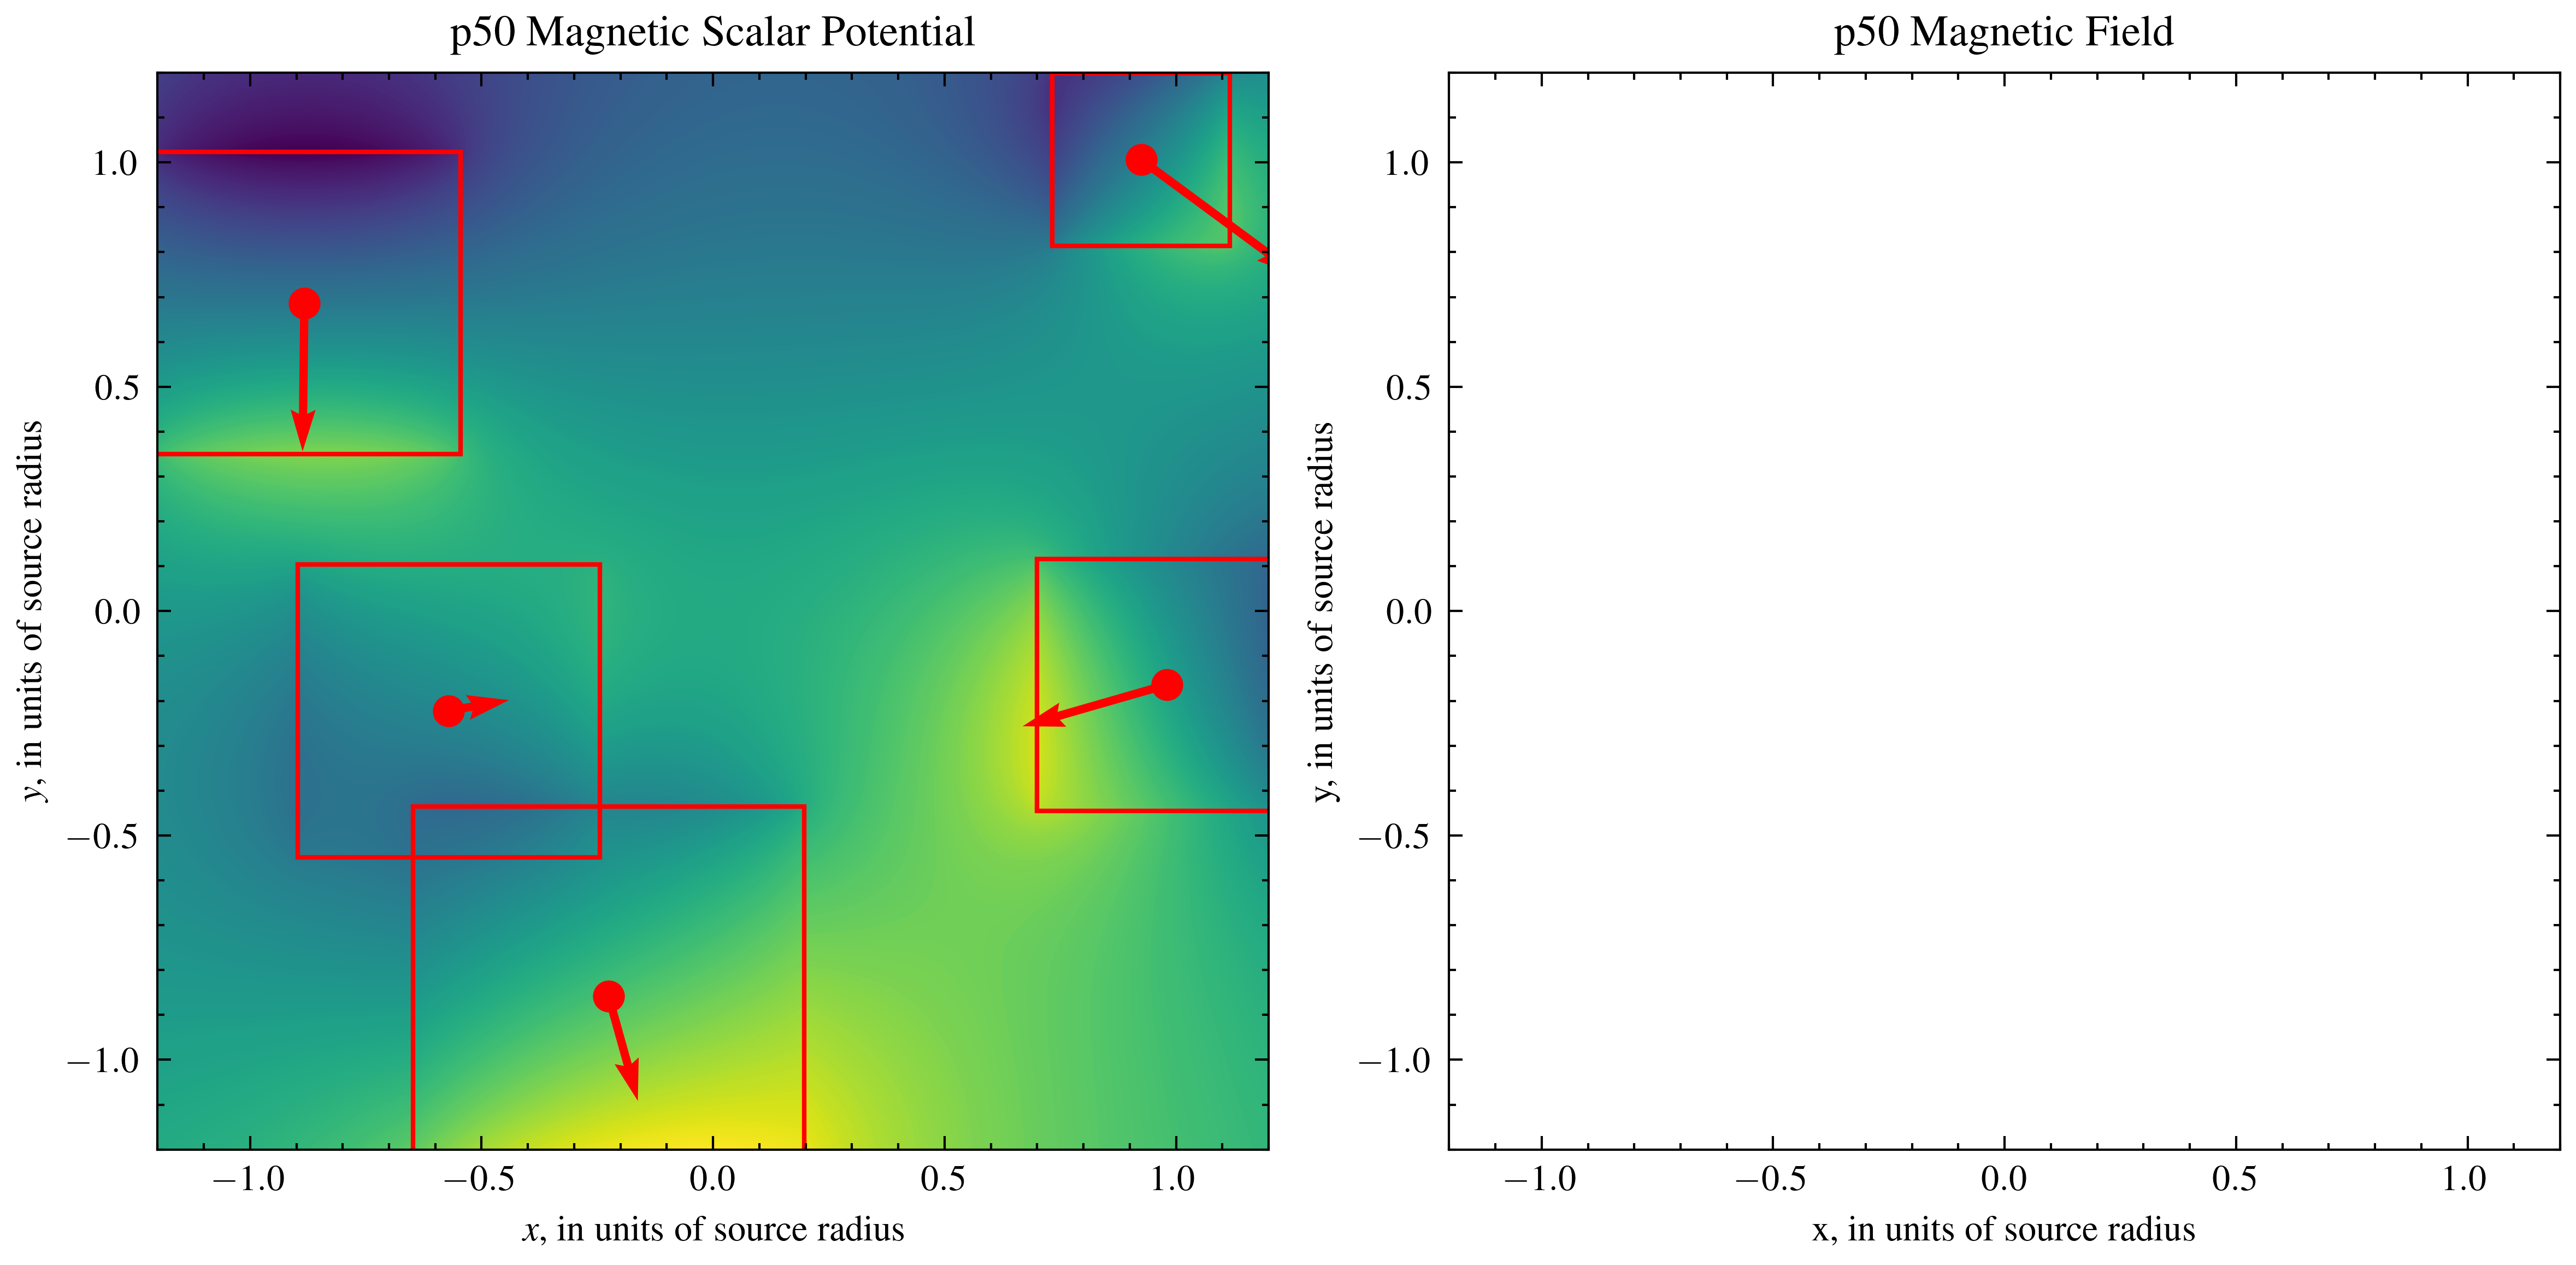

In [3]:
train = read_db("eval_large_m_p50_100_42_5_5.h5")
# train = read_db("train_res32_large_m_42_200000_1.h5")
extra_n = 'p50'
res = int(np.sqrt(train['msp_grid'].shape[1]))
# Stats of dataset
print("Res:", res, "Max size:", train["max_size"], "Min size:", train["min_size"])

idx = 0
vmax = 3.75
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
# scatter = plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=train["msp"][idx], s=0.1, edgecolors='none', norm=norm, cmap='viridis')
# cbar = plt.colorbar(scatter)
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/gt_{extra_n}_plot_{idx}.svg")
plots(train, loc=True, edge=True, idx=idx, output="save", prefix="p50")

3.4294138 -3.7287576


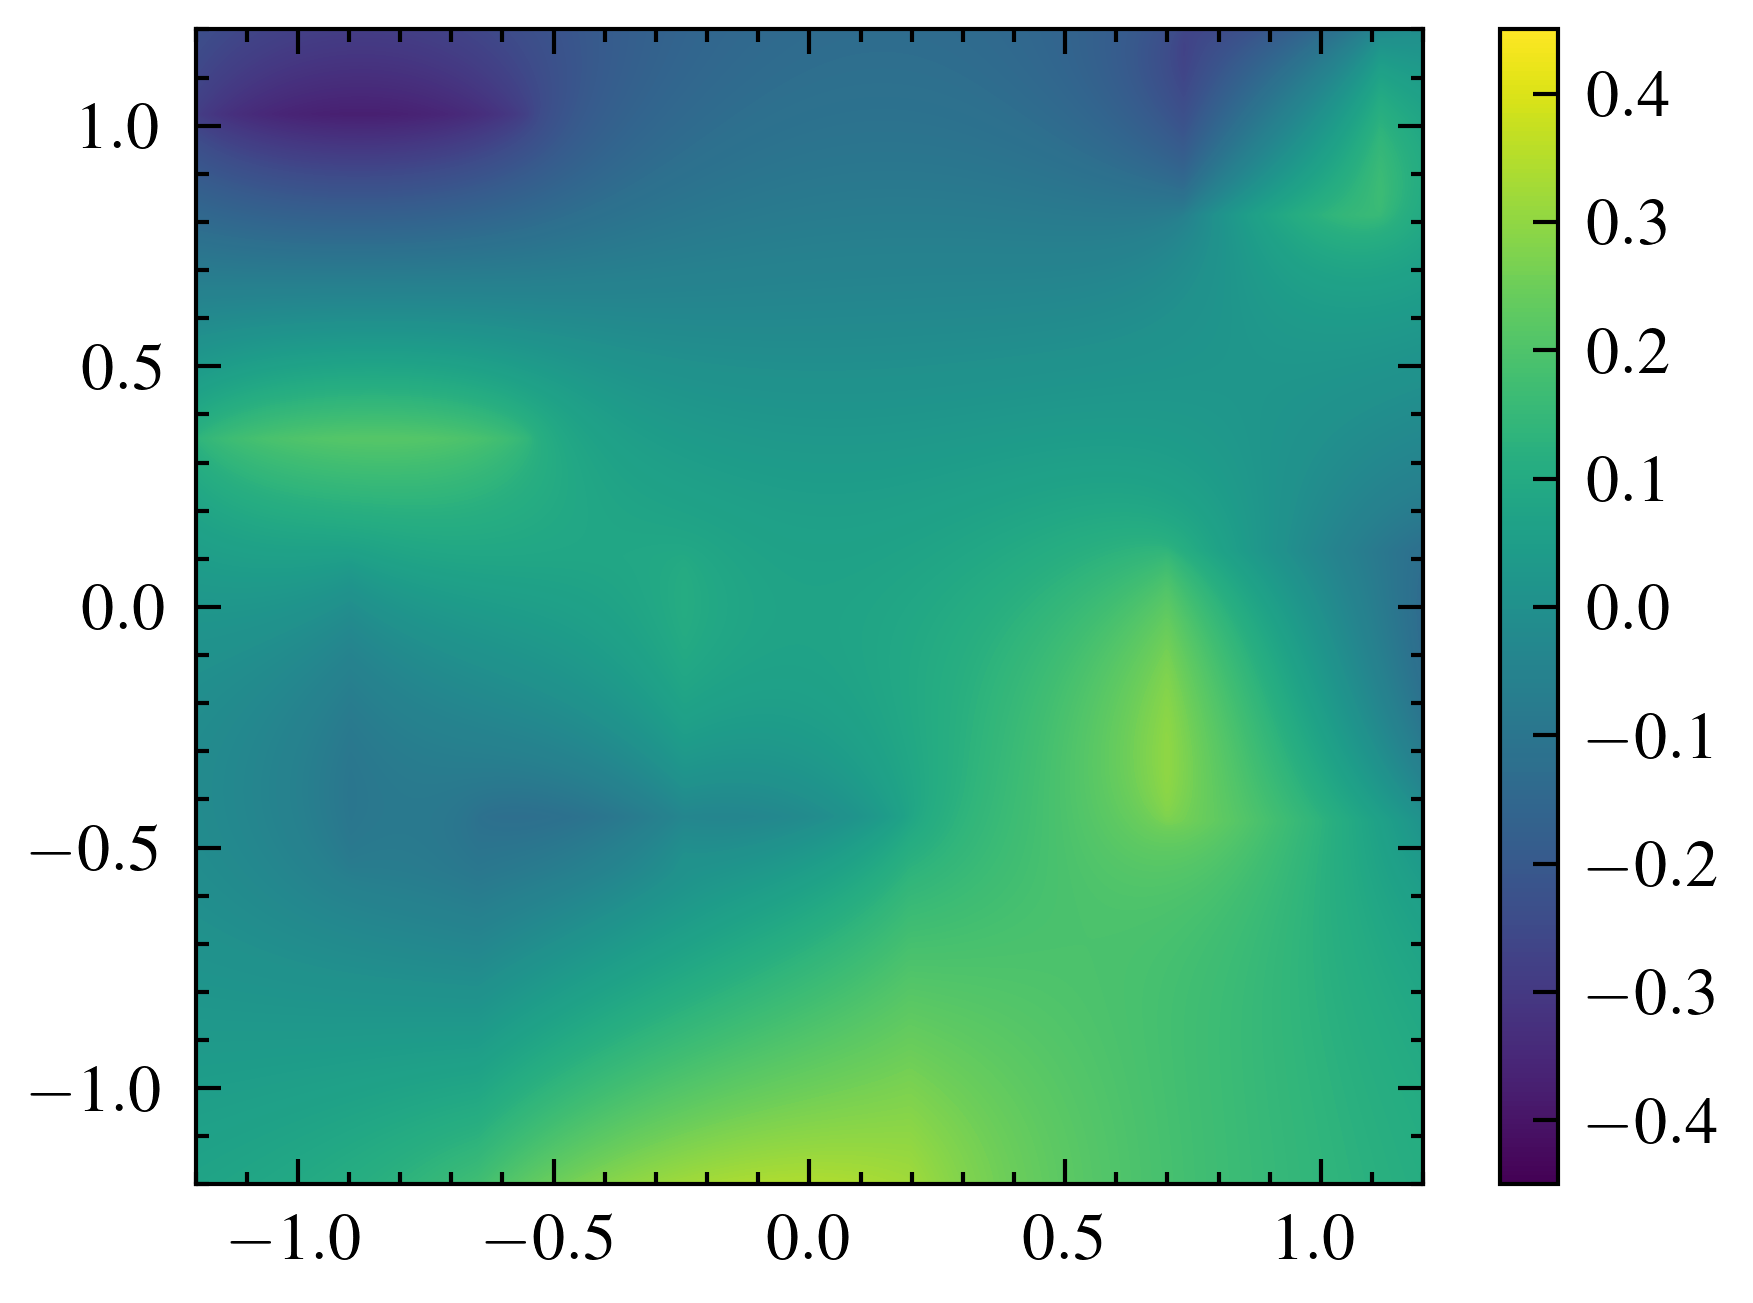

In [7]:
x_grid = np.array(train['grid'][:, 0].reshape((res, res)))
y_grid = np.array(train['grid'][:, 1].reshape((res, res)))
t_msp = train["msp_grid"][idx].reshape((res, res))
print(t_msp.max(), t_msp.min())
vmax = 4.5 / 10
vmin = -4.5 / 10
cbar_ticks = np.linspace(-4/10, 4/10, 9)

# norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 250)  # evenly spaced, symmetric levels
contour = plt.contourf(x_grid, y_grid, np.clip(t_msp / 10, vmin, vmax), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

plt.savefig(f"/home/spol/repos/hypermagnetics/figs/gt_{extra_n}_plot_{idx}.svg")

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


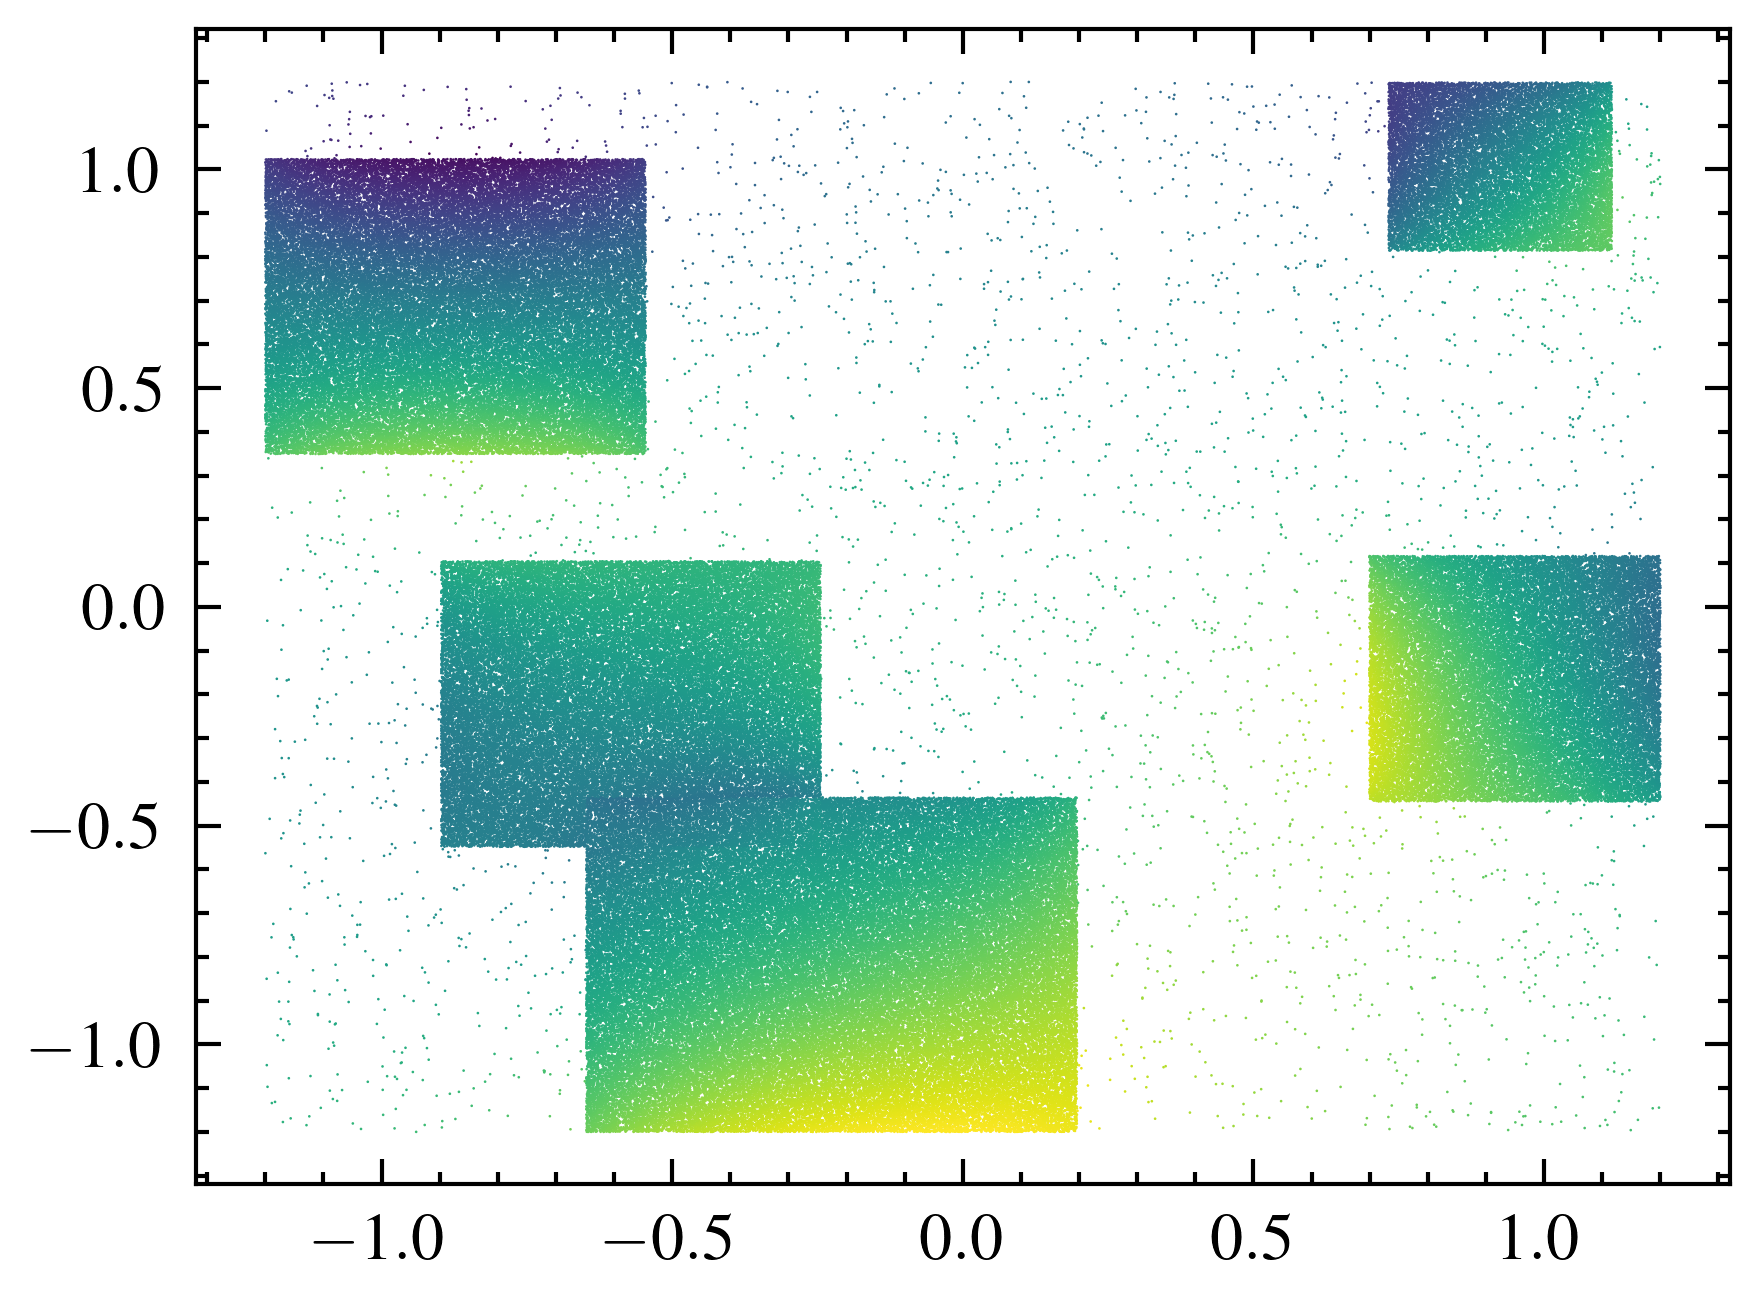

In [24]:
sim = train.copy()
# sim['msp_grid'], _, _ = potential2D(sim['sources'], sim['shape'], sim['grid'], prism_mt=True)
sim_fmm, _, _ = potential2D(sim['sources'][idx:idx+1], sim['shape'], train["r"][idx], prism_mt=True)
plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=sim_fmm, s=0.1, edgecolors='none')

# ### Potential
# x_grid = np.array(train['grid'][:, 0].reshape((res, res)))
# y_grid = np.array(train['grid'][:, 1].reshape((res, res)))
# sim_msp = sim["msp_grid"][idx].reshape((res, res))
# t_msp = train["msp_grid"][idx].reshape((res, res))
# # plt.contourf(x_grid, y_grid, np.clip(np.abs((sim_msp - t_msp)) / np.abs(t_msp), 1e-8, 10))
# # arr = np.clip(np.abs((sim_msp - t_msp)) / np.abs(t_msp), 1e-8, 10)
# # cf = plt.contourf(x_grid, y_grid, arr, norm=LogNorm(vmin=1e-8, vmax=10))
# # plt.colorbar(cf)
# contour = plt.contourf(x_grid, y_grid, np.clip(sim_msp/10, vmin, vmax), levels=levels, cmap='viridis', norm=norm)
# cbar = plt.colorbar(contour)
# cbar.set_ticks(cbar_ticks)
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fmm_{extra_n}_plot_{idx}.png", dpi=300)

# print("Potential:", np.nanmean(np.abs(sim_msp - t_msp)))

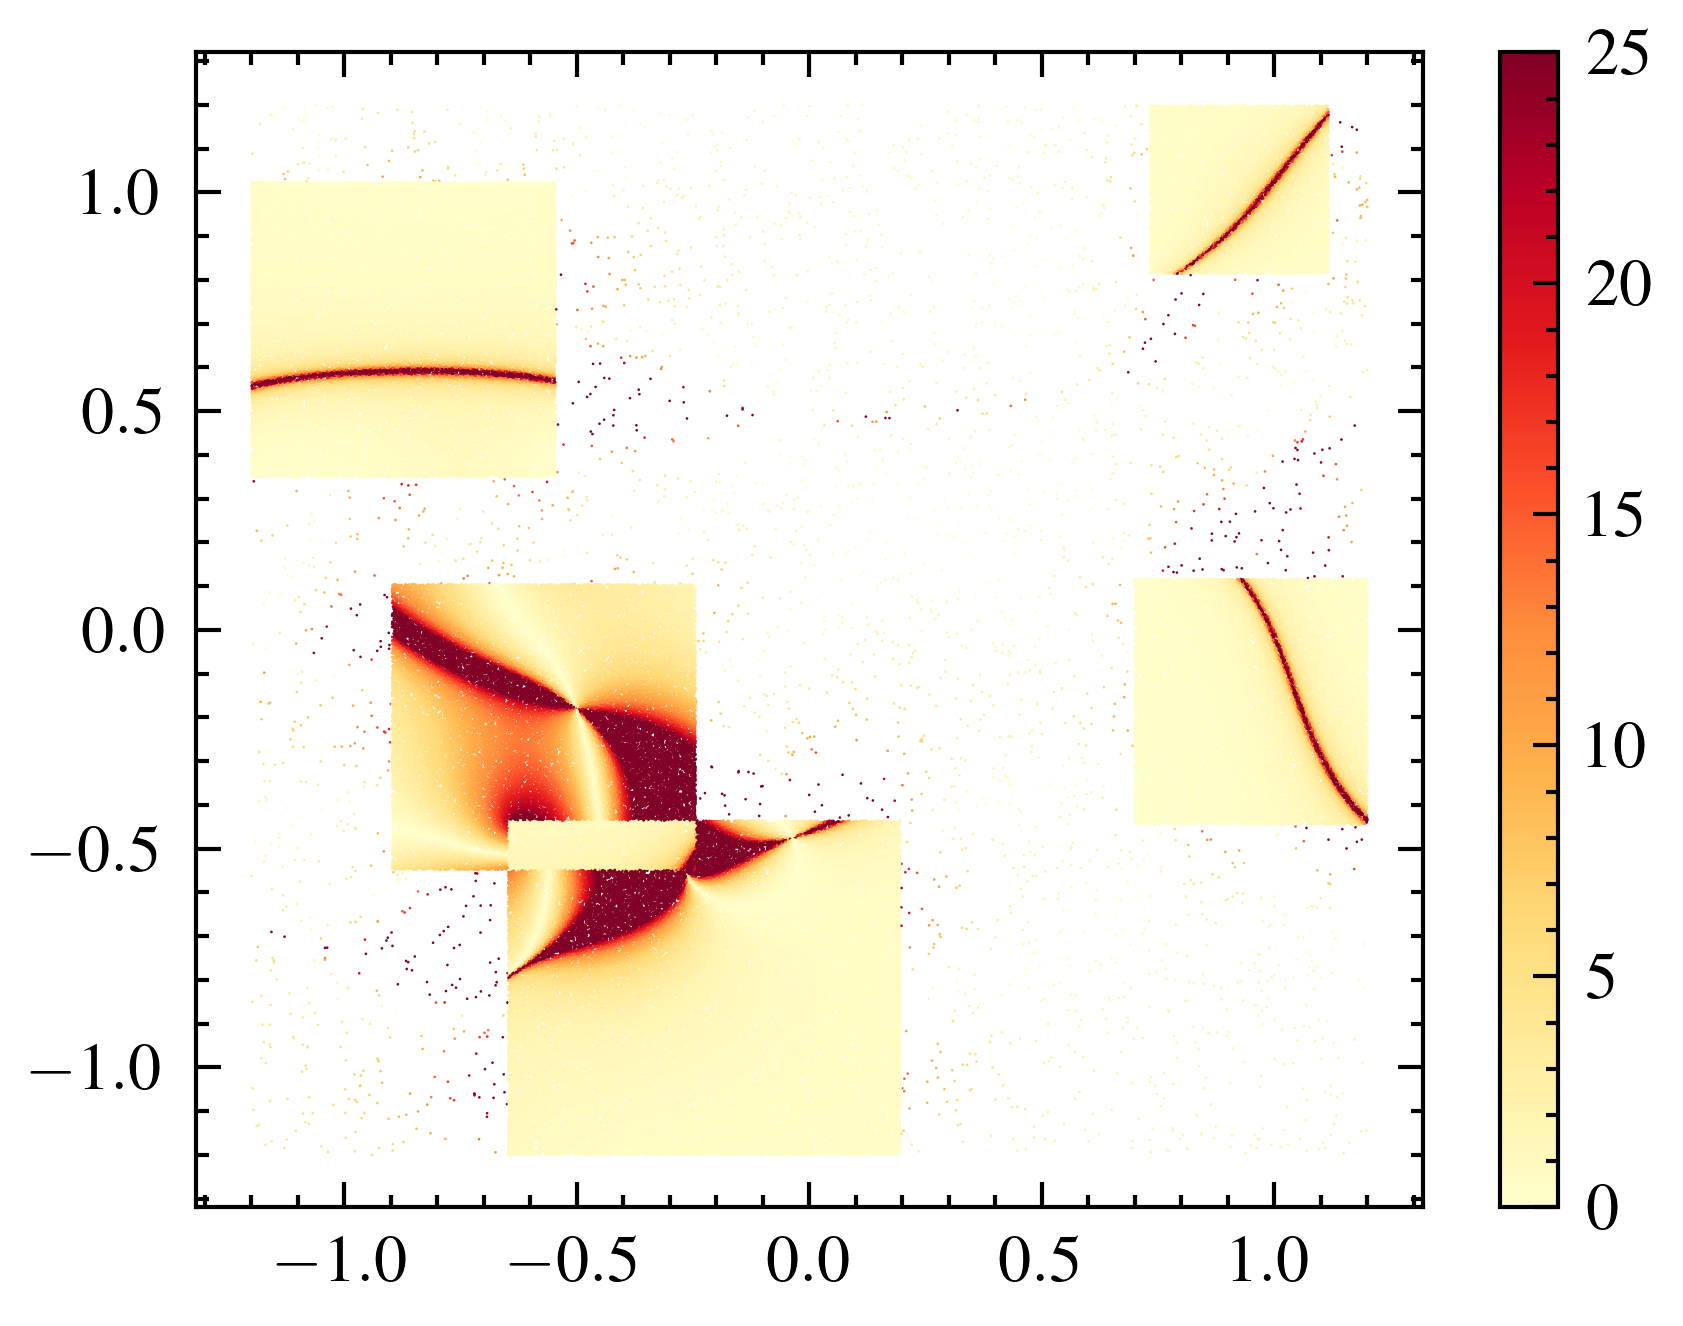

In [25]:
# Error
# err = (np.abs(sim_msp - t_msp) / np.abs(t_msp)) * 100
err = (np.abs(sim_fmm - train["msp"][idx]) / np.abs(train["msp"][idx])) * 100
scatter_rel = plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=err, s=0.1, edgecolors='none', cmap="YlOrRd", vmin=0, vmax=25)
vmax_rel = 25
cbar = plt.colorbar(scatter_rel)
cbar.set_ticks(np.linspace(0, vmax_rel, vmax_rel//5 + 1))
plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fmm_{extra_n}_relerr_plot_{idx}.png", dpi=300)

# print(err.max(), err.min())
# vmax_rel = 25
# cbar_ticks_rel = np.linspace(0, vmax_rel, vmax_rel//5 + 1)

# levels_rel = np.linspace(0, vmax_rel, 250)  # evenly spaced, symmetric levels
# contour_rel = plt.contourf(x_grid, y_grid, np.clip(err, 0, vmax_rel), cmap="YlOrRd", levels=levels_rel)
# cbar = plt.colorbar(contour_rel)
# cbar.set_ticks(cbar_ticks_rel)
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fmm_{extra_n}_relerr_plot_{idx}.png", dpi=300)

Mean: 20.518905678215063
Median: 1.168265436478206


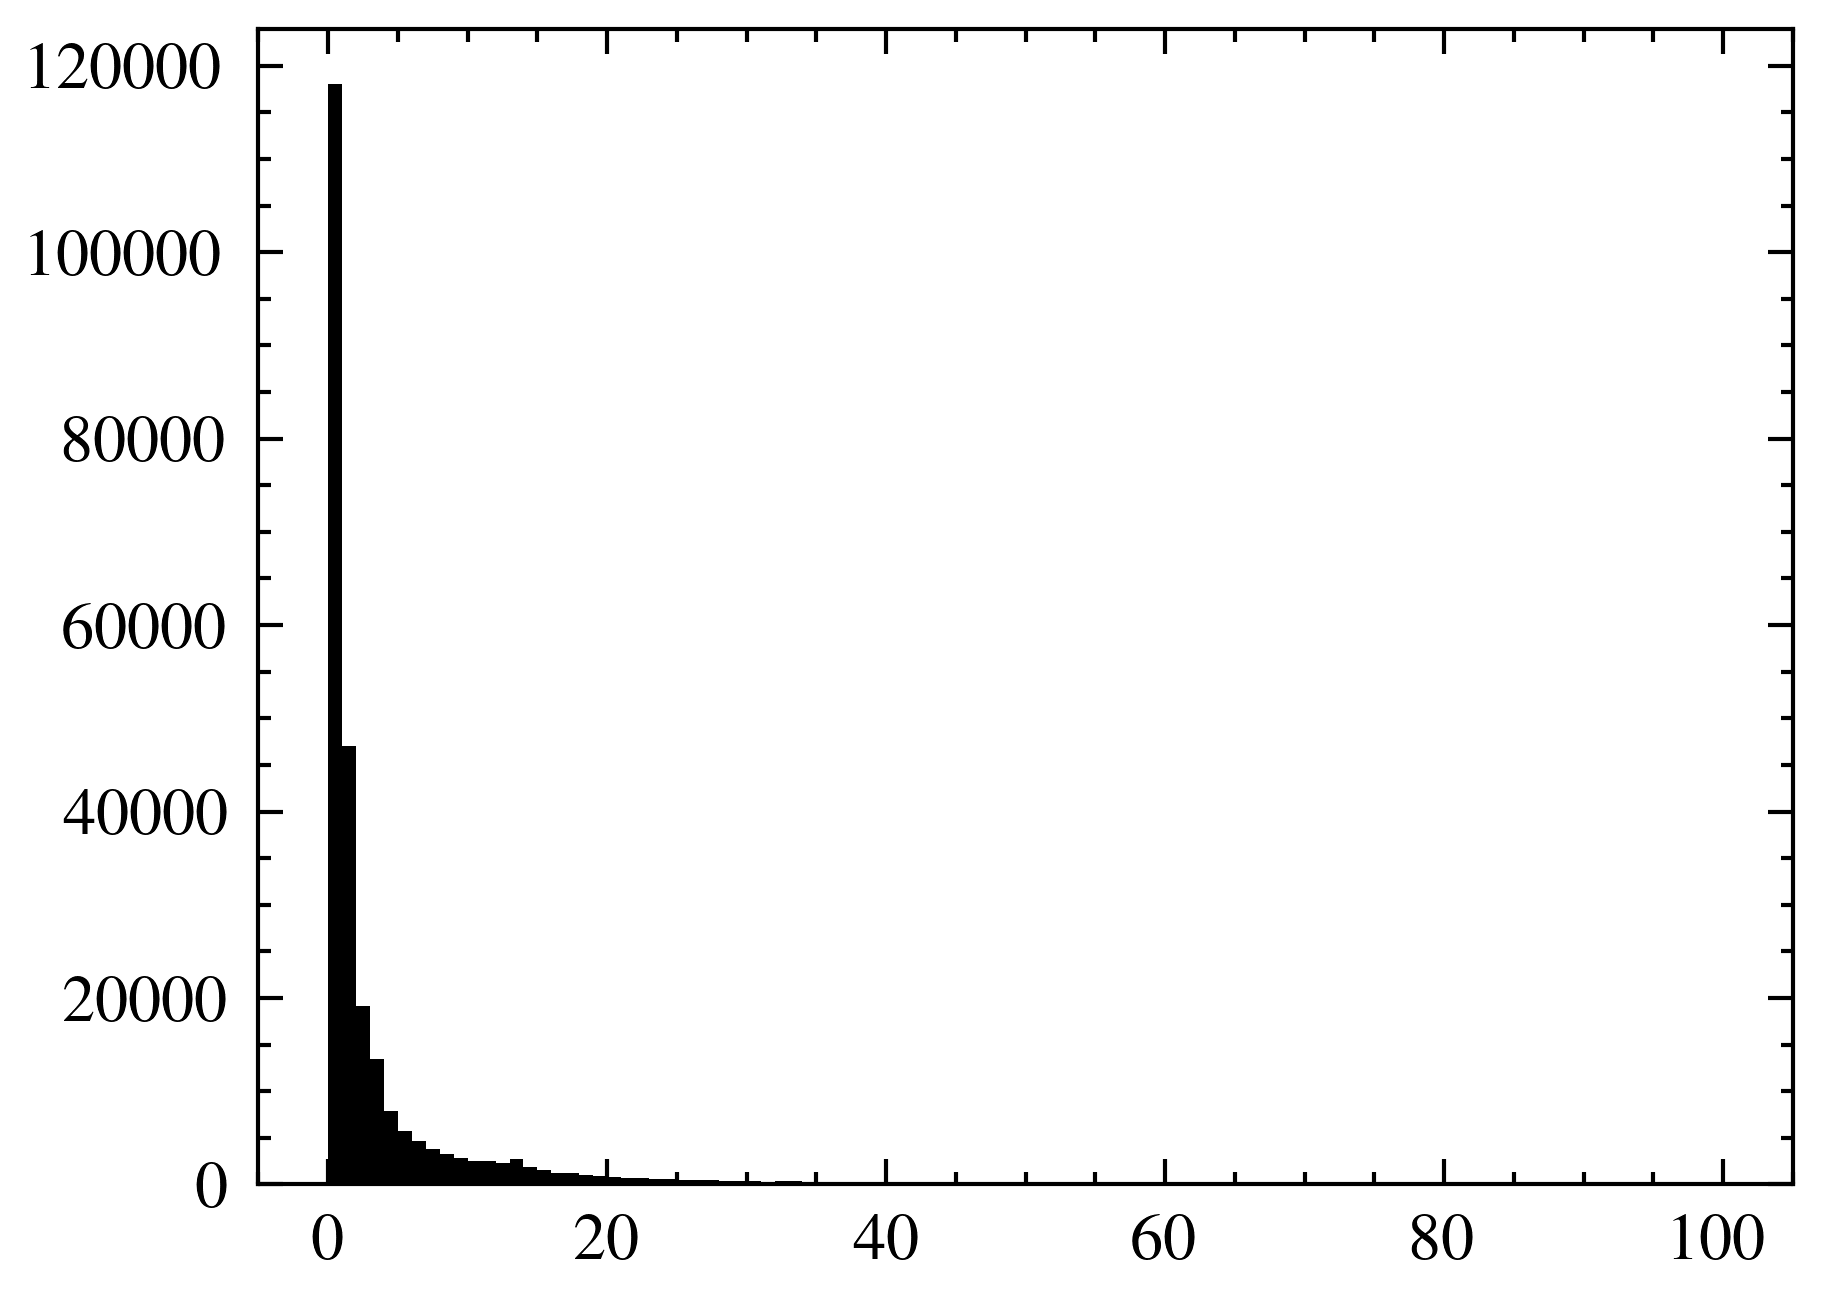

In [26]:
plt.hist(err.flatten(), bins=100, range=(0, 100))
print("Mean:", np.mean(err))
print("Median:", np.median(err))

## Directly from FMM2D

Field(y): 1.327333006223316


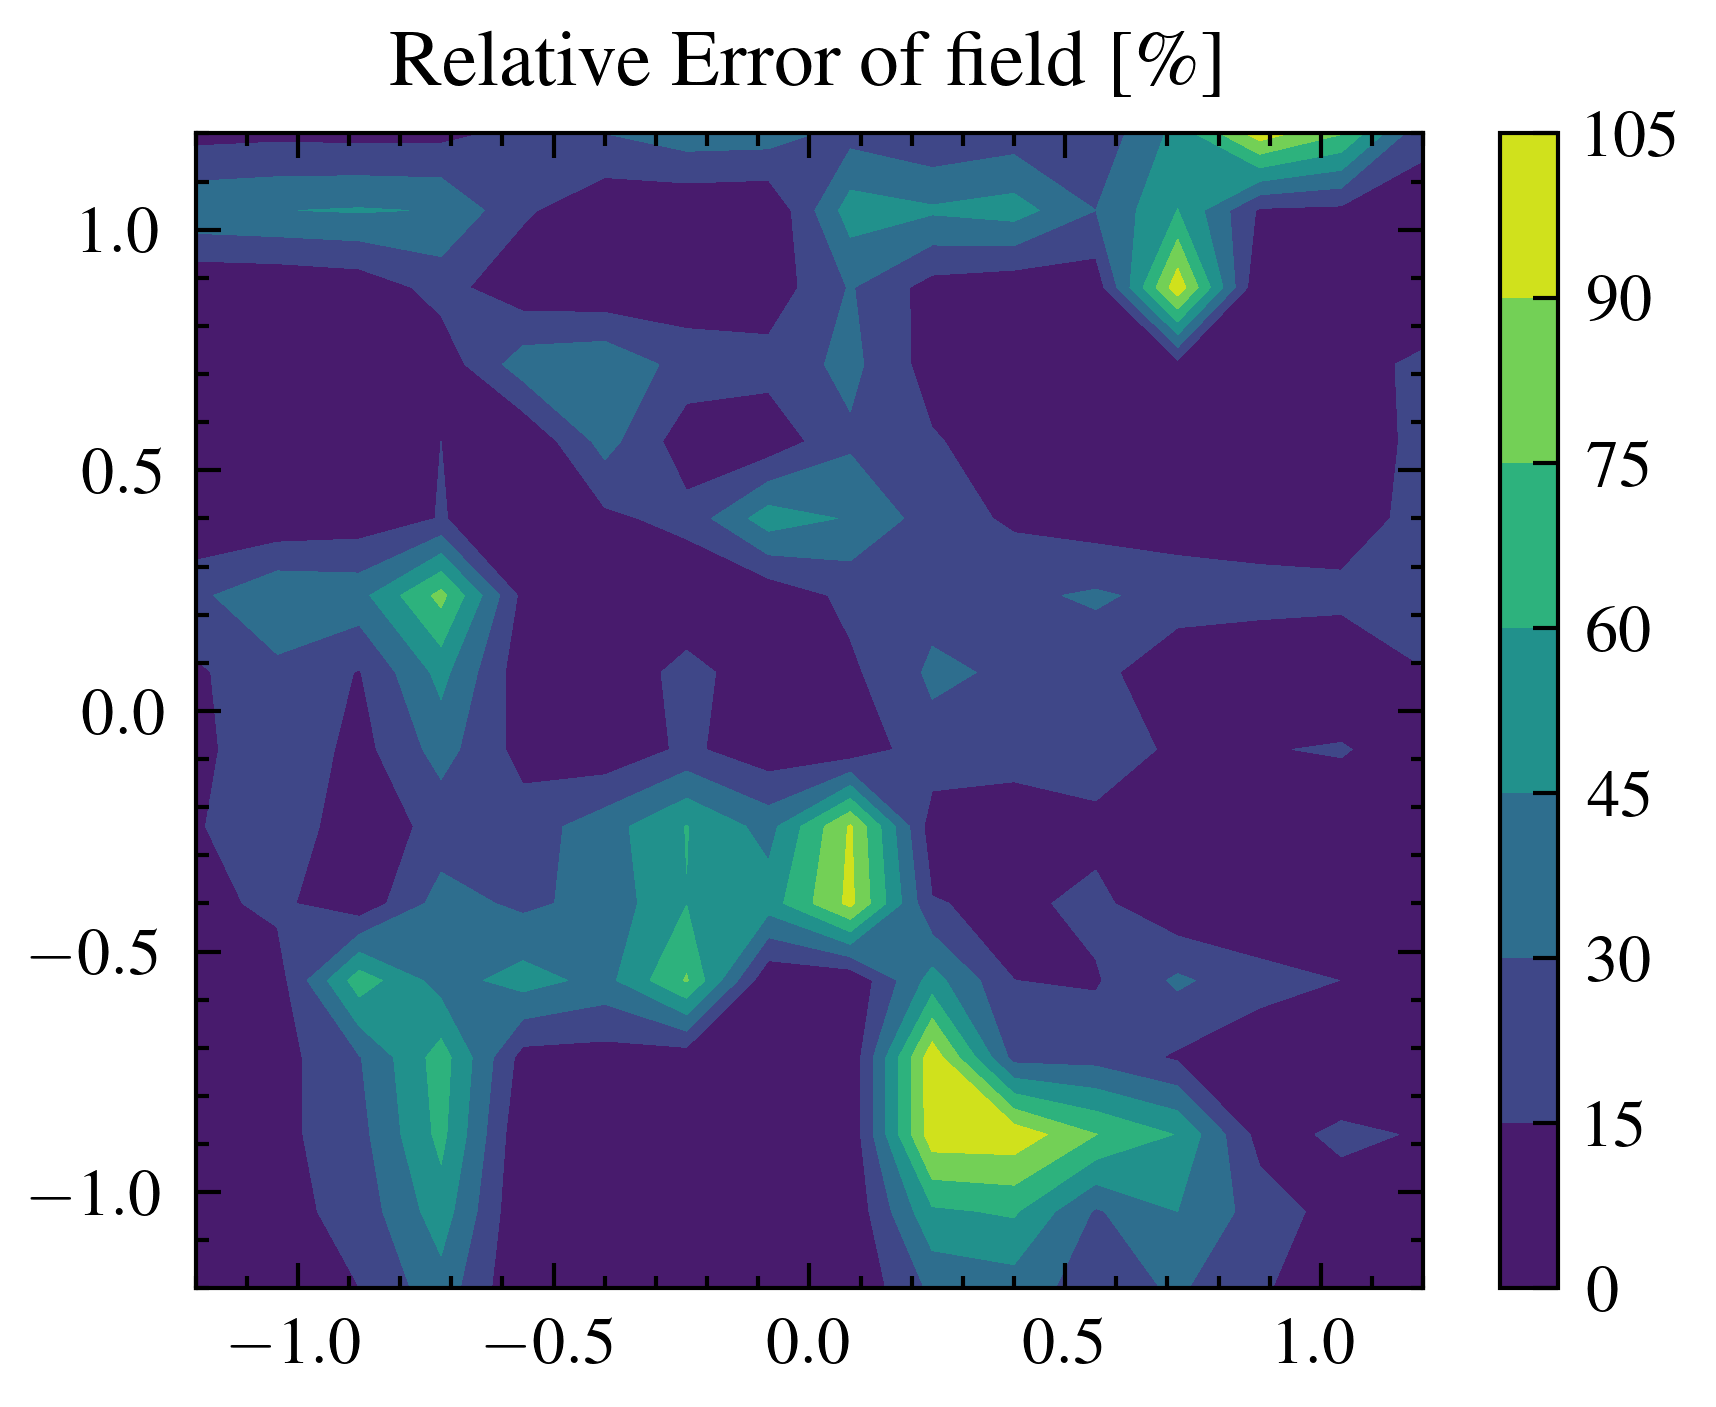

In [ ]:
_, sim['field_grid_direct'], _ = potential2D(sim['sources'], sim['shape'], sim['grid'], prism_mt=True)

### Field in x-direction
x_grid = np.array(train['grid'][:, 0].reshape((res, res)))
y_grid = np.array(train['grid'][:, 1].reshape((res, res)))
sim_f = sim["field_grid_direct"][0, ...]
t_f = train["field_grid"][0, ..., :2]
diff = np.linalg.norm(np.abs(sim_f - t_f), axis=-1).reshape((res, res))
norm_f = np.linalg.norm(t_f, axis=-1).reshape((res, res))
# plt.contourf(x_grid, y_grid, np.clip(sim_f[...,1], -5, 5))
# plt.contourf(x_grid, y_grid, np.clip(t_f[...,1], -1, 1))
plt.contourf(x_grid, y_grid, np.clip((diff / norm_f) * 100, 0, 100))
plt.title("Relative Error of field [\%]")
# plt.contourf(x_grid, y_grid, np.clip(sim_f[...,1] / t_f[...,1], 0, 3))
plt.colorbar()

print("Field(y):", np.nanmean(np.abs(sim_f[...,1] / t_f[...,1])))

## Equivalent for MagTense
2D magnetiziation in $xy$-plane and prism is elongated in $z$-direction.

Convert magnetic moment to magnetization: $M = m / (2 * a * 2 * b)$

1.0000000625970107


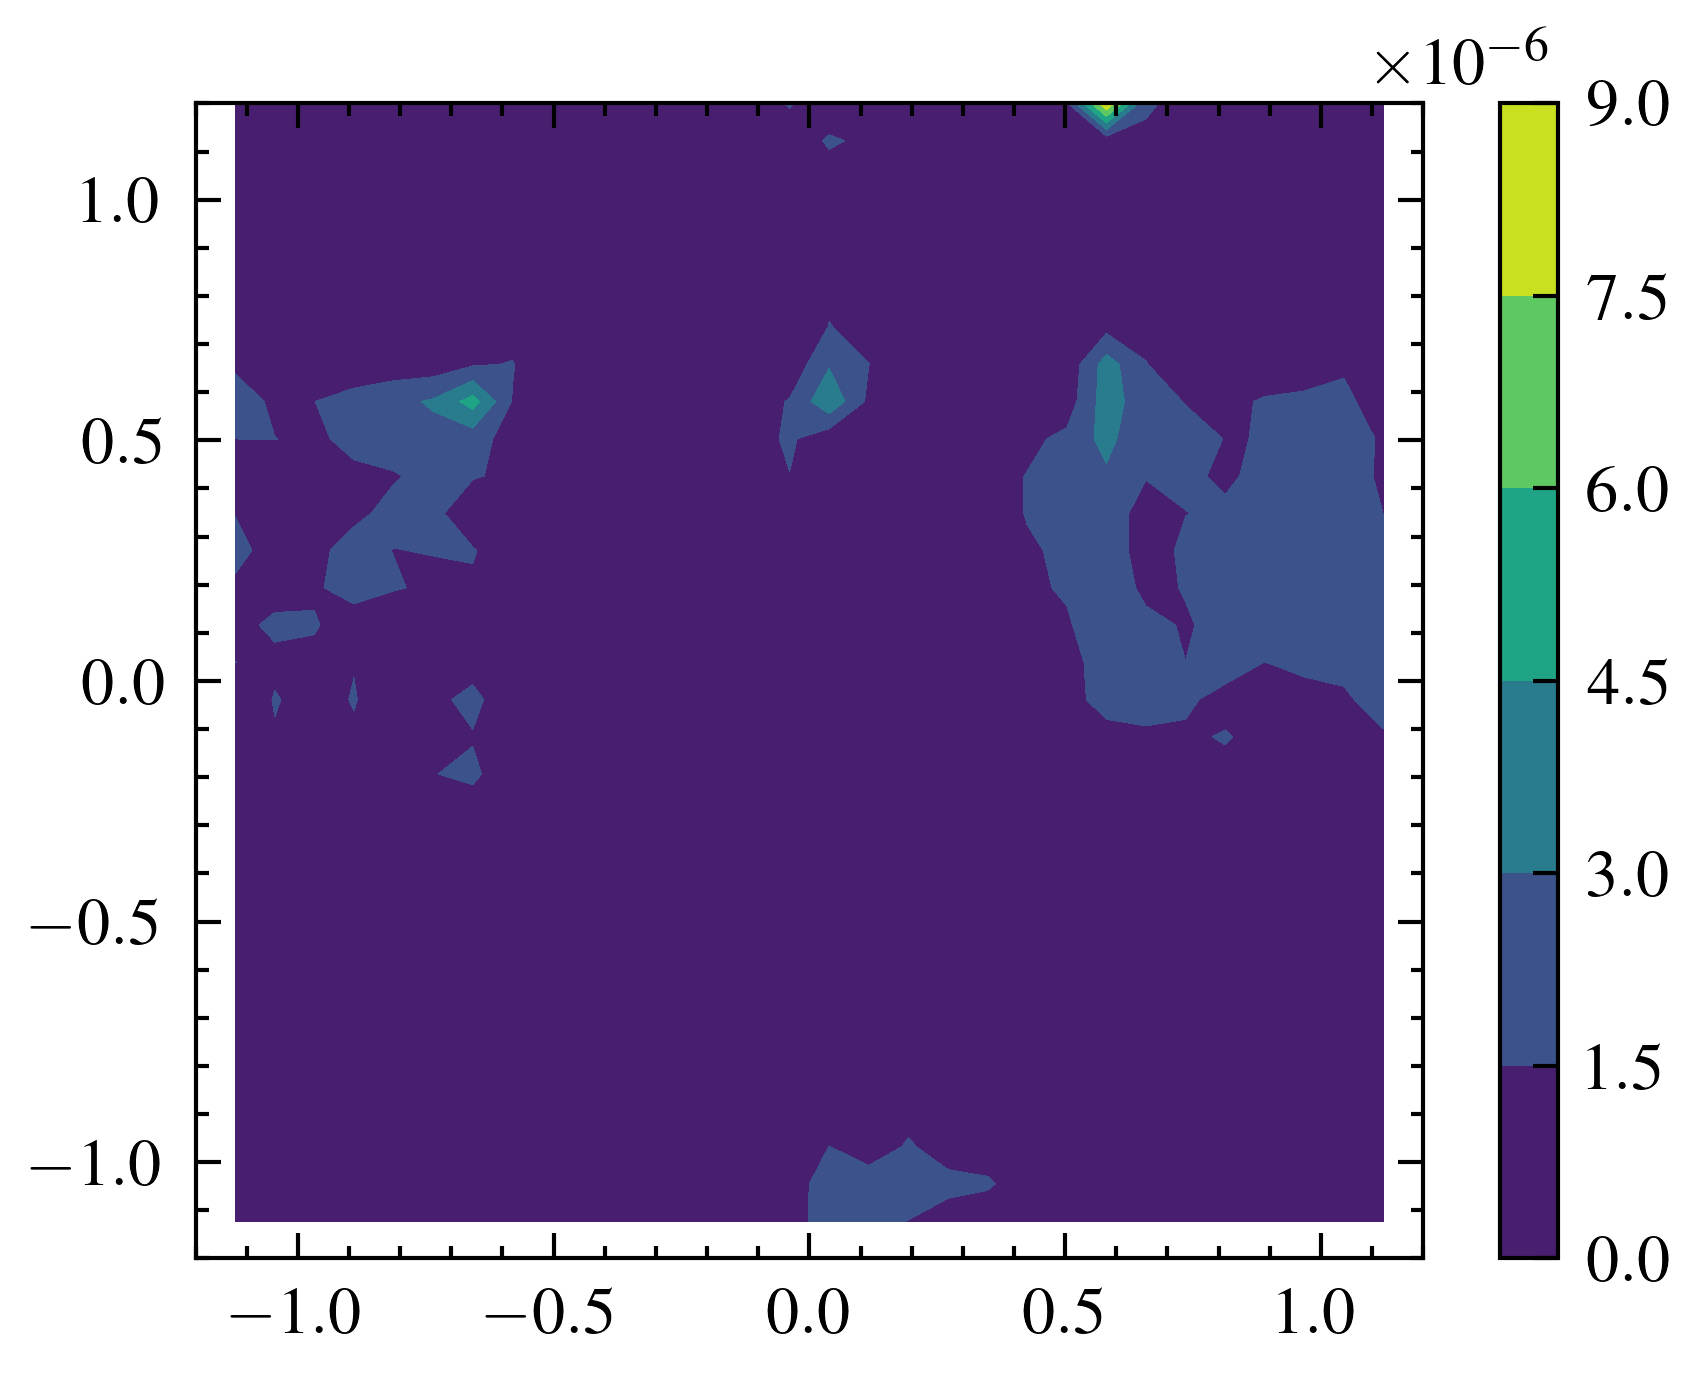

In [ ]:
mt_sim, _ = field_mt(train['sources'], train['grid'], "prism")

x_grid_pr = np.array(train['grid'][:, 0].reshape((res, res)))
y_grid_pr = np.array(train['grid'][:, 1].reshape((res, res)))
mt_f_grid_x = np.array(mt_sim[idx, ..., 0].reshape((res, res)))
t_f = train["field_grid"][idx, ..., 0].reshape((res, res))
plt.contourf(x_grid_pr, y_grid_pr, np.clip(np.abs(mt_f_grid_x - t_f), 0, 1))
plt.colorbar()
print(np.nanmean(np.abs(mt_f_grid_x / t_f)))

In [ ]:
for eps in [0, 1e-3, 1e-5, 1e-7, 1e-9]:
    # print("Source 1 on all other locations")
    # source = train['sources'][0:1, 0:1]
    # loc = train['r'][0][1:]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field, _ = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Other sources on source 1")
    # source = train['sources'][0:1, 1:]
    # loc = train['r'][0][0:1]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field, _ = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Source 1 on all locations")
    source = train['sources'][0:1, 0:1]
    loc = train['r'][0]
    mt_sim_s, _ = field_mt(source, loc + eps, train['shape'])
    # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    _, fmm_field, _ = potential2D(source, train['shape'], loc + eps)
    # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    rel_err = np.abs((mt_sim_s[..., :2] - fmm_field) / mt_sim_s[..., :2]) * 100
    print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")
    print(fmm_field[0, 0, :2])
    print(mt_sim_s[0, 0, :2])
    print("\n")

Eps: 0.0e+00, Mean Error: 9.29 [%], Median Error: 5.17 [%]
[-3.24945998 -0.59239304]
[-3.24203955 -0.59104027]


Eps: 1.0e-03, Mean Error: 9.41 [%], Median Error: 5.16 [%]
[-3.25030276 -0.57450311]
[-3.2420385  -0.59103453]


Eps: 1.0e-05, Mean Error: 10164.93 [%], Median Error: 6.19 [%]
[ 481.3439815  1111.54757297]
[-3.24203955 -0.59104027]


Eps: 1.0e-07, Mean Error: 41831117.51 [%], Median Error: 6.19 [%]
[  787608.07475877 -4801188.98301804]
[-3.24203955 -0.59104027]


Eps: 1.0e-09, Mean Error: 9.29 [%], Median Error: 5.17 [%]
[-3.24945998 -0.59239304]
[-3.24203955 -0.59104027]




# FC-ILR field plots

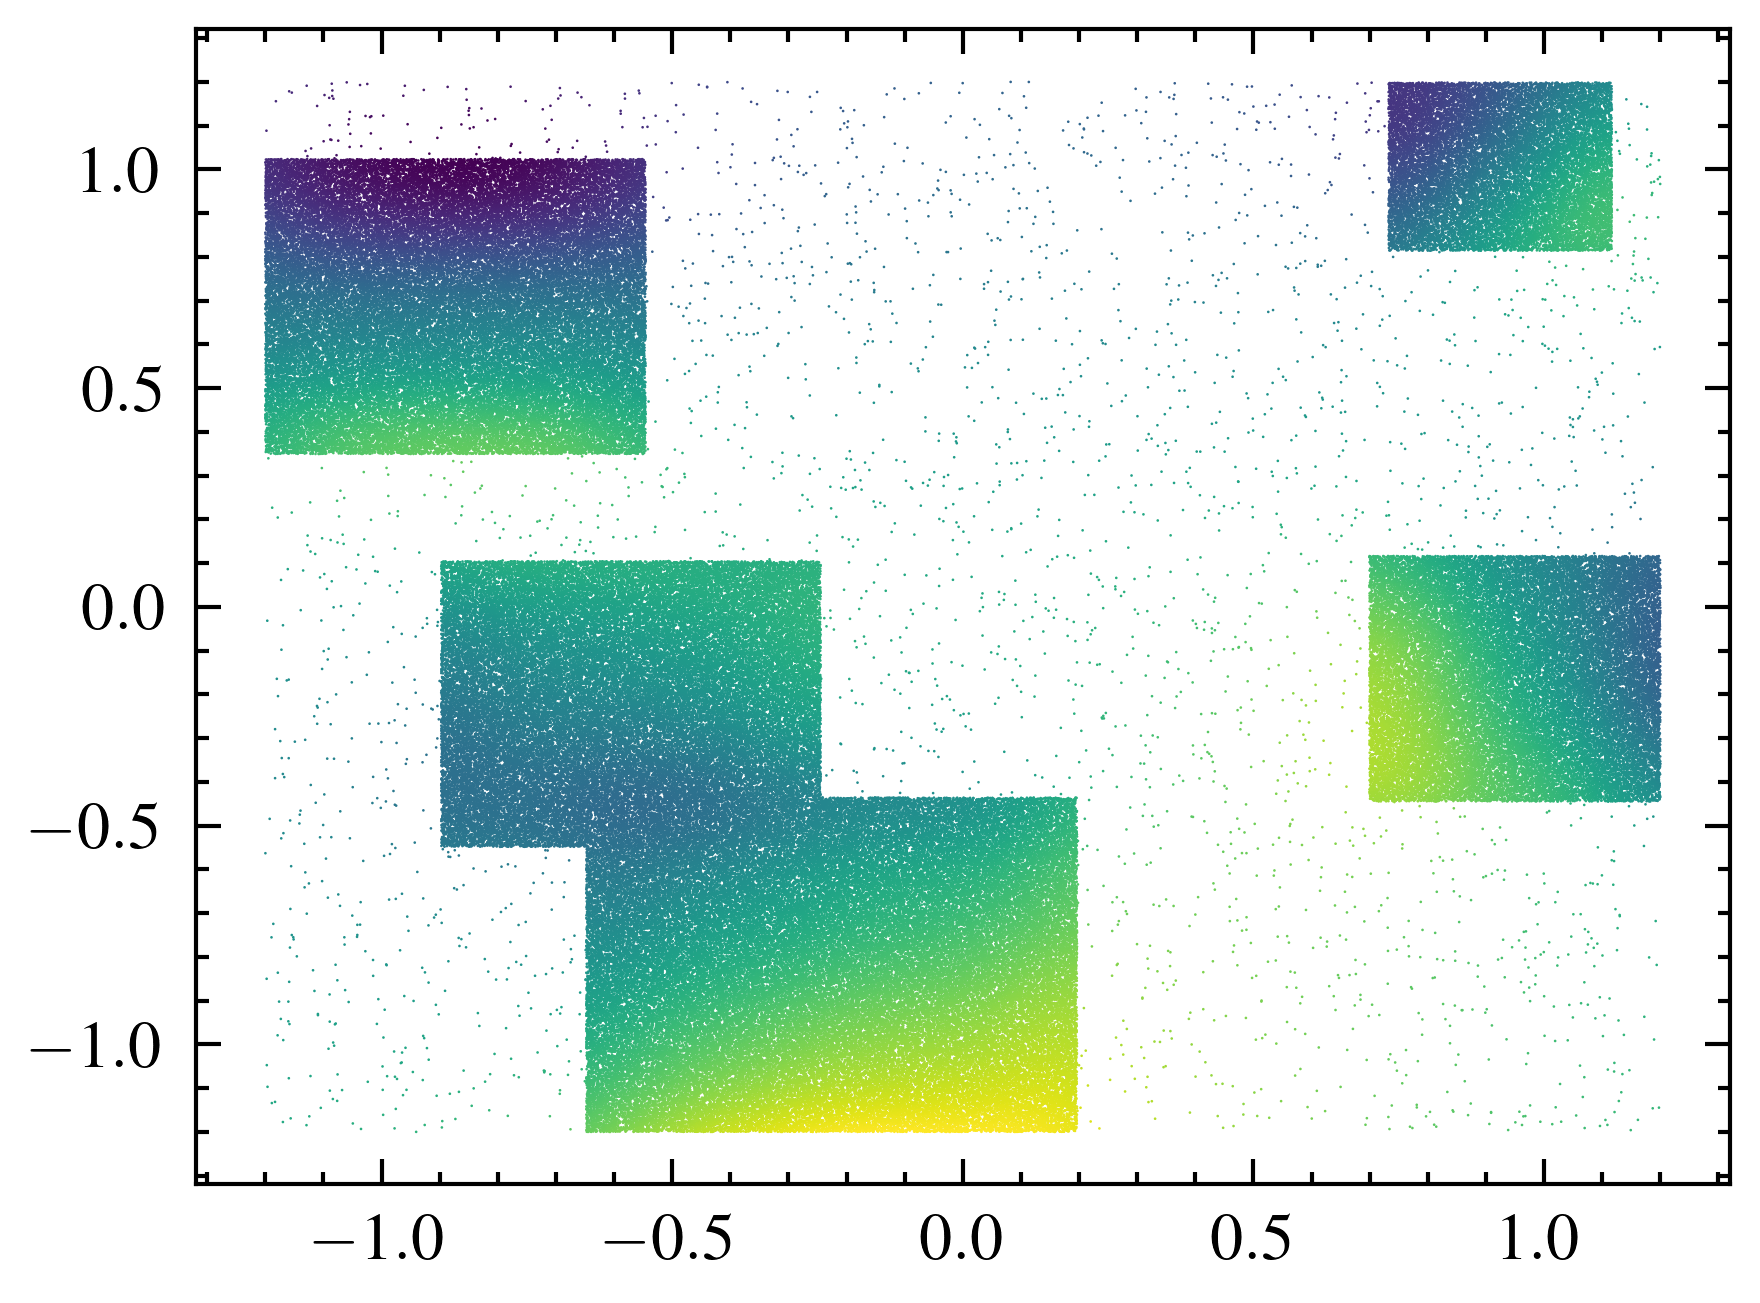

In [27]:
model_cfg = HyperLayer(
    width=400,
    depth=3,
    hwidth=2,
    hdepth=3,
    seed=42,
)

model_folder = Path().resolve() / '..' / 'models'
model_path = f"{model_folder}/fc_ilr_400_200k_res32_large_m.eqx"
model = eqx.tree_deserialise_leaves(model_path, model_cfg)

sim = train.copy()
sim_f = jax.vmap(model, in_axes=(0, None))(
    train['sources'][idx:idx+1], train["r"][idx]
)[0]
plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=sim_f, s=0.1, edgecolors='none')

# sim['field_grid_model'] = jax.vmap(model.field, in_axes=(0, None))(
#     train['sources'][idx:idx+1], train['grid']
# )[0]
# sim['msp_grid_model'] = jax.vmap(model, in_axes=(0, None))(
#     train['sources'][idx:idx+1], train['grid']
# )[0]

# x_grid = np.array(train['grid'][:, 0].reshape((res, res)))
# y_grid = np.array(train['grid'][:, 1].reshape((res, res)))
# sim_f = sim["msp_grid_model"].reshape((res, res))

# contour = plt.contourf(x_grid, y_grid, sim_f/10, levels=levels, cmap='viridis', norm=norm)
# cbar = plt.colorbar(contour)
# cbar.set_ticks(cbar_ticks)
# # plt.contourf(x_grid, y_grid, np.clip((diff / norm_f) * 100, 0, 100))
# # plt.title("Relative Error of field [\%]")
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_{extra_n}_plot_{idx}.png", dpi=300)

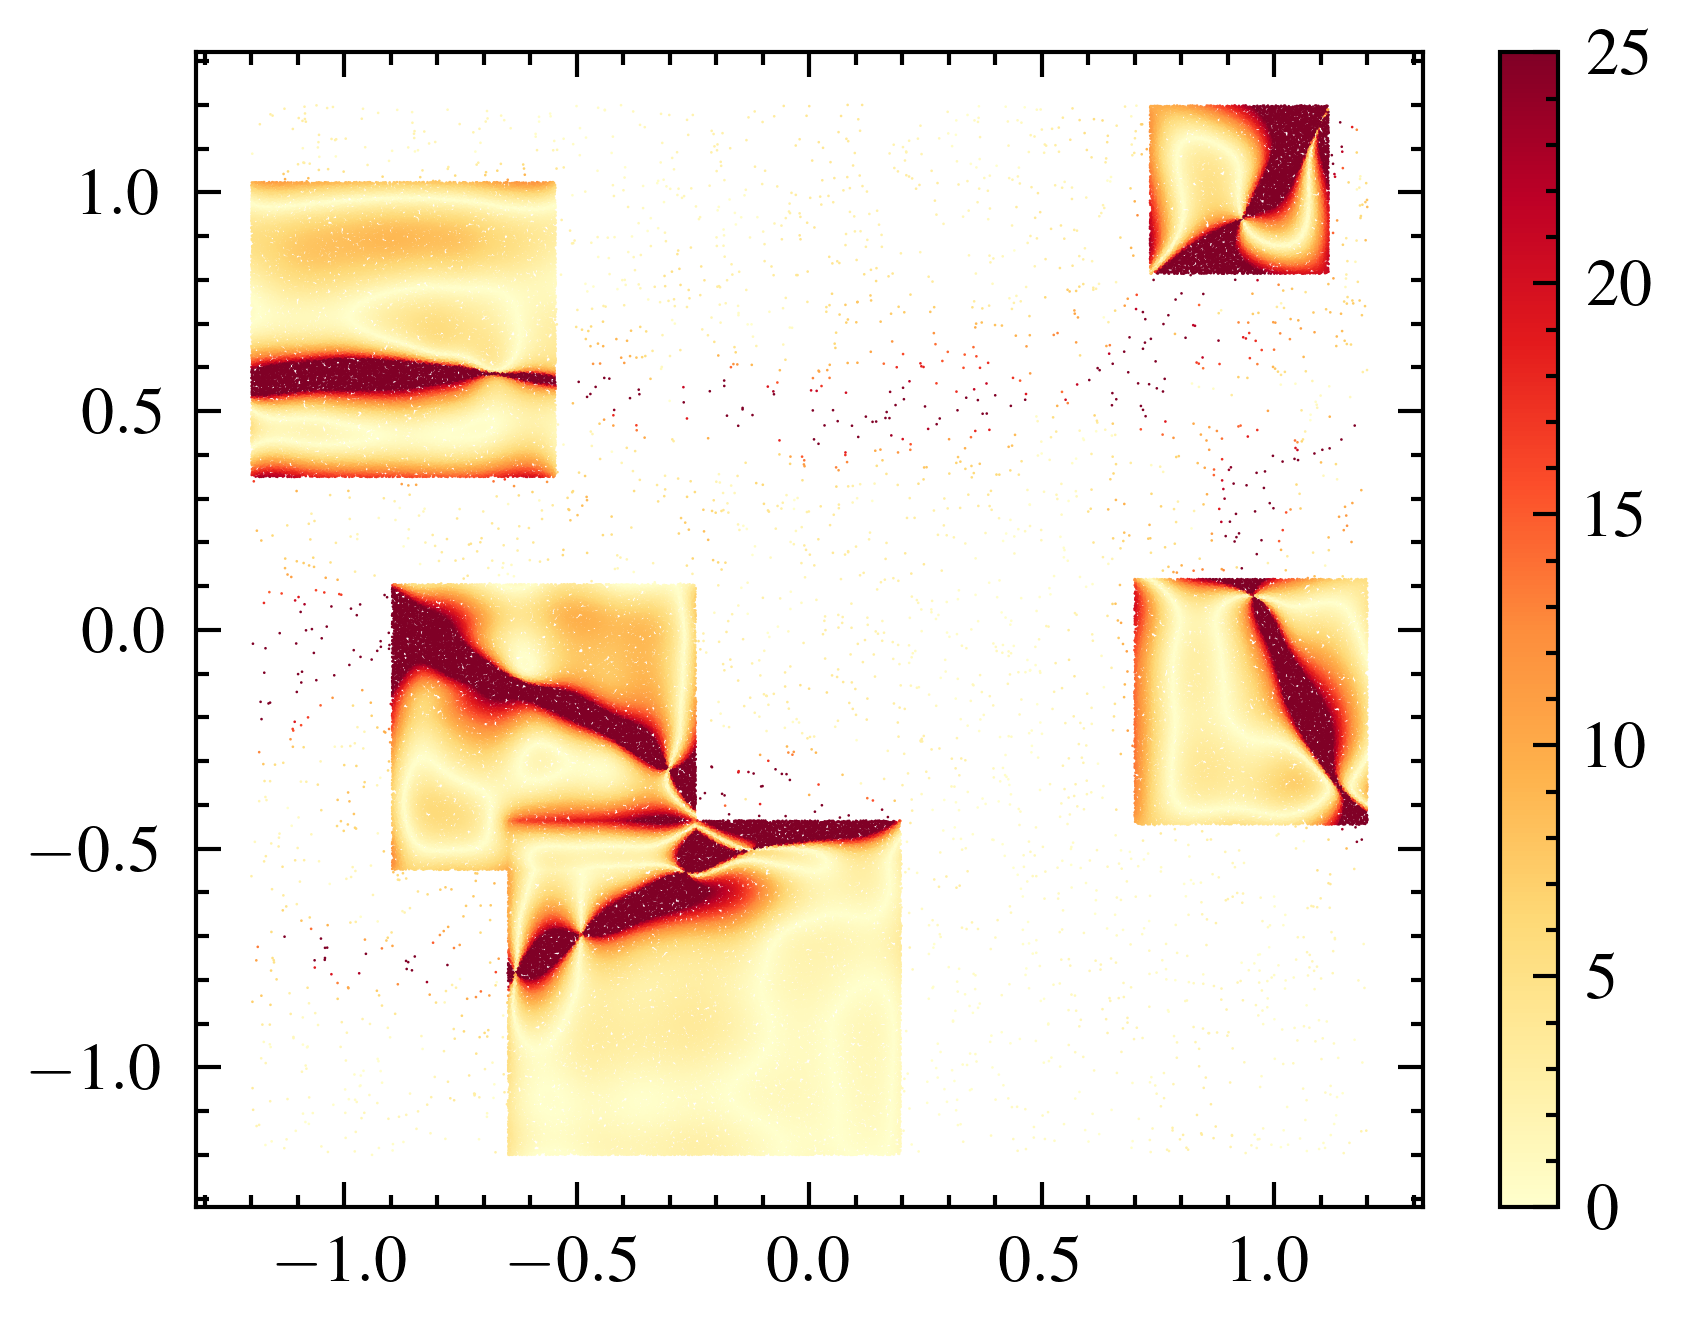

In [28]:
# # Error FCILR
# err_fcilr = (np.abs(sim_f - t_msp) / np.abs(t_msp)) * 100
# contour_rel = plt.contourf(x_grid, y_grid, np.clip(err_fcilr, 0, vmax_rel), cmap="YlOrRd", levels=levels_rel)
# cbar = plt.colorbar(contour_rel)
# cbar.set_ticks(cbar_ticks_rel)
# plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_relerr_{extra_n}_plot_{idx}.png", dpi=300)

err_fcilr = (np.abs(sim_f - train["msp"][idx]) / np.abs(train["msp"][idx])) * 100
scatter_rel = plt.scatter(train["r"][idx][:,0], train["r"][idx][:,1], c=err_fcilr, s=0.1, edgecolors='none', cmap="YlOrRd", vmin=0, vmax=25)
vmax_rel = 25
cbar = plt.colorbar(scatter_rel)
cbar.set_ticks(np.linspace(0, vmax_rel, vmax_rel//5 + 1))
plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_relerr_{extra_n}_plot_{idx}.png", dpi=300)

Mean: 32.93100144317412
Median: 3.9571780224255044


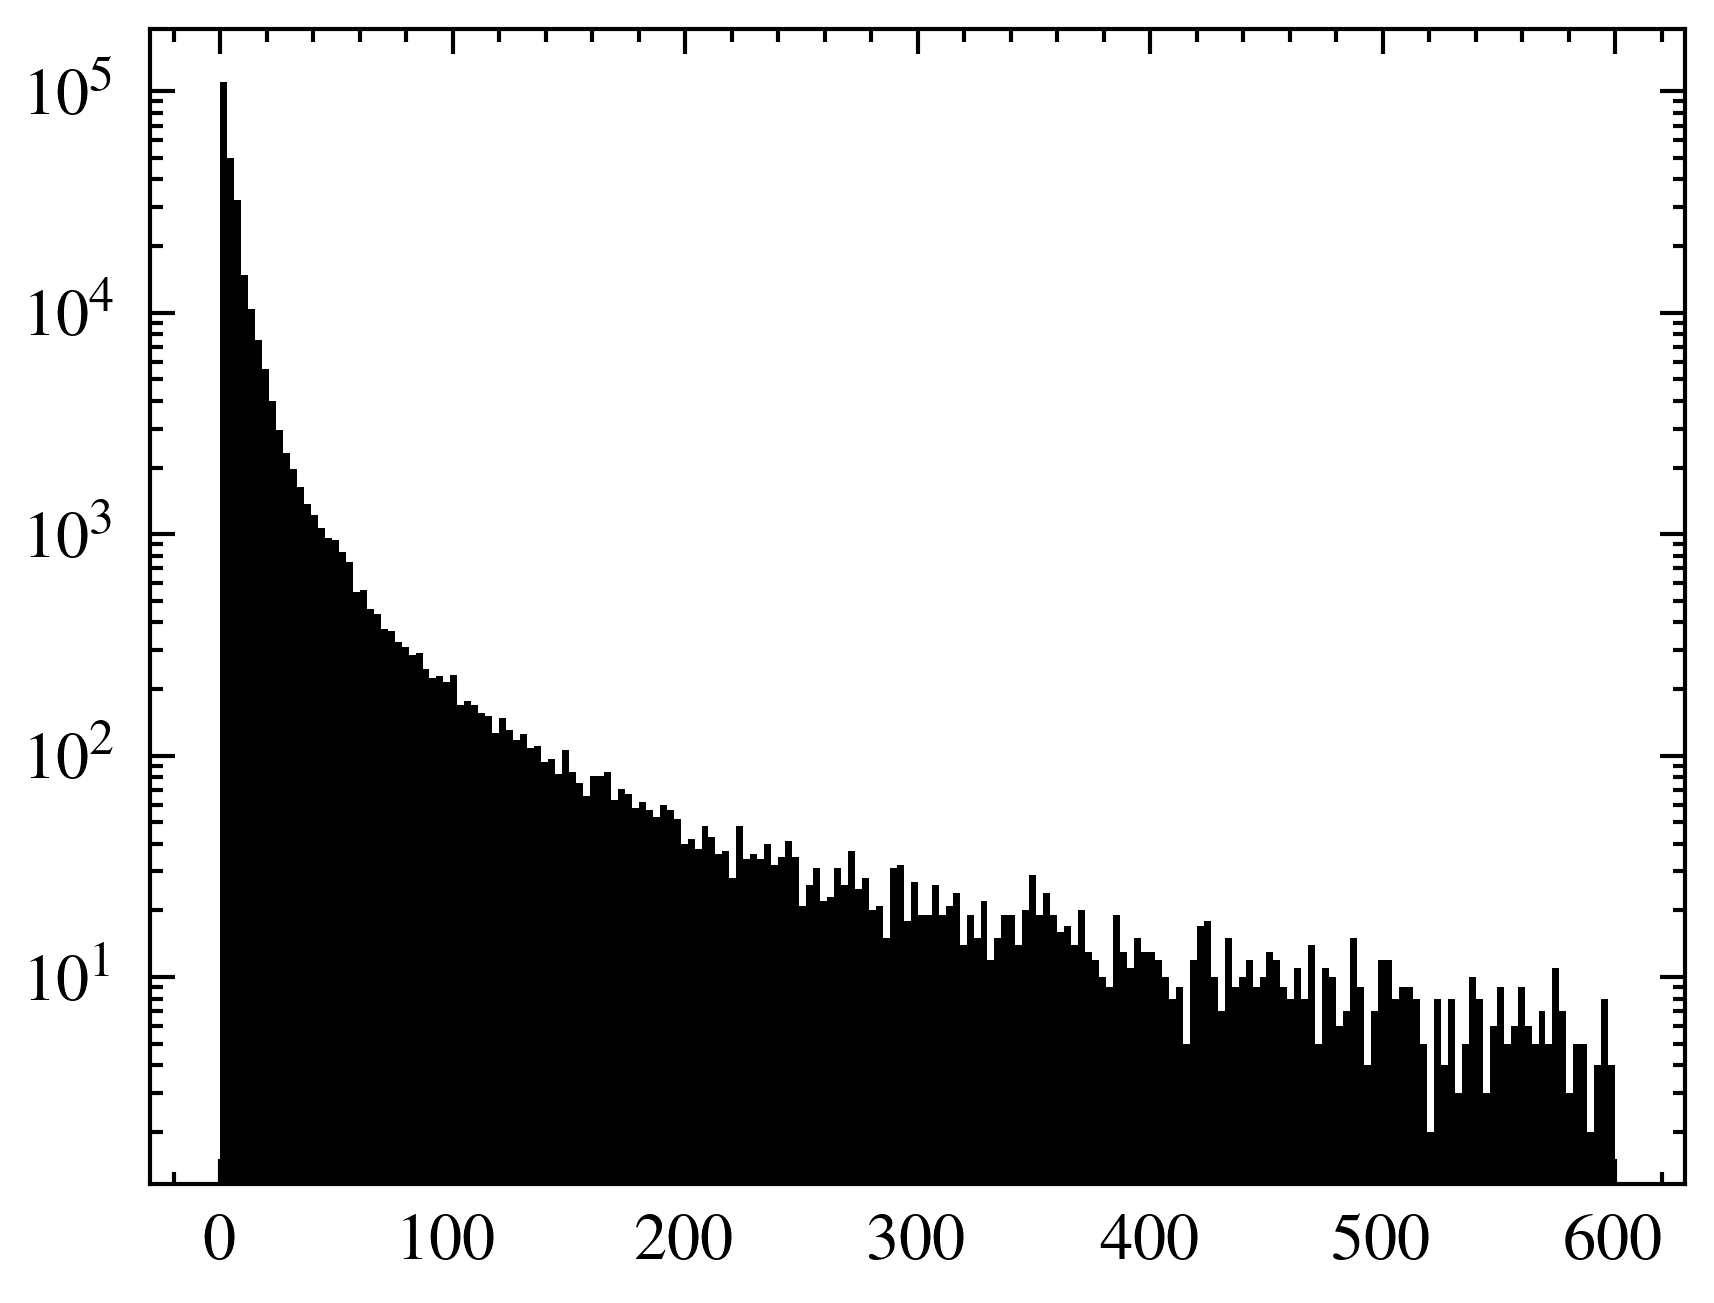

In [29]:
plt.hist(err_fcilr.flatten(), bins=200, range=(0, 600))
plt.yscale("log")
print("Mean:", np.mean(err_fcilr))
print("Median:", np.median(err_fcilr))
plt.savefig(f"/home/spol/repos/hypermagnetics/figs/fcilr_relerr_{extra_n}_hist_{idx}.png", dpi=300)